# Pursuit–evasion

Questo notebook usa il BRT euclideo già calcolato per:

1. visualizzare una sezione tridimensionale nello spazio `(x_rel, y_rel, theta_rel)`;
2. visualizzare una fetta bidimensionale nel piano `(x_rel, y_rel)`;
3. scegliere lo stato iniziale;
4. simulare il gioco pursuit–evasion;
5. mostrare l'animazione e i grafici.

## 1. Import e individuazione del progetto

In [1]:
%load_ext autoreload
%autoreload 2

import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from IPython.display import HTML, display
from matplotlib.colors import TwoSlopeNorm

current_directory = Path.cwd().resolve()
candidate_directories = (
    current_directory,
    *current_directory.parents,
)

project_root = next(
    (
        directory
        for directory in candidate_directories
        if (
            directory
            / "scripts"
            / "simulate_pursuit_evasion.py"
        ).is_file()
        and (
            directory
            / "examples"
            / "pursuit_evasion.ipynb"
        ).is_file()
        and (directory / "setup.py").is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Repository root not found. Run the notebook "
        "from the repository or one of its subdirectories."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

simulation_script_path = (
    project_root
    / "scripts"
    / "simulate_pursuit_evasion.py"
)

module_specification = importlib.util.spec_from_file_location(
    "simulate_pursuit_evasion",
    simulation_script_path,
)

if (
    module_specification is None
    or module_specification.loader is None
):
    raise ImportError(
        f"Unable to import {simulation_script_path}"
    )

sim = importlib.util.module_from_spec(
    module_specification
)
sys.modules[module_specification.name] = sim
module_specification.loader.exec_module(sim)

print("Project root:", project_root)
print("Simulation script:", Path(sim.__file__).resolve())

Project root: /home/alessio-grisorio/TESI/hj_reachability
Simulation script: /home/alessio-grisorio/TESI/hj_reachability/scripts/simulate_pursuit_evasion.py


## 2. Configurazione

Scegliere:

- la sezione del BRT da visualizzare;
- il punto iniziale della simulazione;
- durata e passo temporale.

`[x_rel, y_rel, theta_rel, v_H, delta_E, v_E]`.

In [ ]:
# File BRT
BRT_PATH = (
    project_root
    / "results"
    / "brt"
    / "euclidean.npz"
)

# Valori fissati per la sezione 3D e per la fetta 2D
SLICE_THETA_REL_DEG = 0.0
SLICE_V_H = 6.0
SLICE_DELTA_E_DEG = 0.0
SLICE_V_E = 8.0

# Scelta dello stato iniziale:
# "manual", "random_negative", "random_positive", "near_boundary"
INITIAL_STATE_MODE = "manual"

# [x_rel, y_rel, theta_rel, v_H, delta_E, v_E]
# Per la modalità manuale gli ultimi quattro valori coincidono
# con quelli della fetta 2D.
MANUAL_INITIAL_STATE = np.array(
    [
        10.0,
        0.0,
        np.deg2rad(SLICE_THETA_REL_DEG),
        SLICE_V_H,
        np.deg2rad(SLICE_DELTA_E_DEG),
        SLICE_V_E,
    ],
    dtype=float,
)

# Simulazione
MAX_SIMULATION_TIME = 3.0
DT = 0.05

# Animazione inline
ANIMATION_FRAME_STRIDE = 1
ANIMATION_FPS = 20

sim.INITIAL_STATE_MODE = INITIAL_STATE_MODE
sim.MANUAL_INITIAL_STATE = MANUAL_INITIAL_STATE
sim.MAX_SIMULATION_TIME = MAX_SIMULATION_TIME
sim.DT = DT

sim.SAVE_RESULTS = False
sim.SAVE_STATIC_FIGURE = False
sim.SAVE_ANIMATION = False
sim.SHOW_STATIC_FIGURE = False
sim.SHOW_ANIMATION_WINDOW = False

sim.ANIMATION_FRAME_STRIDE = ANIMATION_FRAME_STRIDE
sim.ANIMATION_FPS = ANIMATION_FPS

## 3. Caricamento del BRT

In [ ]:
print("BRT path:", BRT_PATH)
print("Exists:", BRT_PATH.is_file())

brt_data = sim.load_saved_brt(BRT_PATH)

grid = brt_data["grid"]
BRT = np.asarray(brt_data["BRT"])
V0 = np.asarray(brt_data["V0"])
coordinate_vectors = [
    np.asarray(vector, dtype=float)
    for vector in grid.coordinate_vectors
]

print("Grid shape:", grid.shape)
print("BRT shape:", BRT.shape)
print("Gradient shape:", brt_data["gradients"].shape)
print("Solver accuracy:", brt_data["metadata"]["solver"]["accuracy"])

BRT path: /home/alessio-grisorio/TESI/hj_reachability/results/brt/euclidean.npz
Exists: True
Grid shape: (26, 13, 15, 8, 21, 8)
BRT shape: (26, 13, 15, 8, 21, 8)
Gradient shape: (26, 13, 15, 8, 21, 8, 6)
Solver accuracy: high


## 4. Selezione dei nodi più vicini ai valori richiesti

In [ ]:
def nearest_index(
    vector: np.ndarray,
    requested_value: float,
) -> int:
    return int(
        np.argmin(
            np.abs(vector - requested_value)
        )
    )


theta_requested = np.deg2rad(
    SLICE_THETA_REL_DEG
)
delta_requested = np.deg2rad(
    SLICE_DELTA_E_DEG
)

i_theta = nearest_index(
    coordinate_vectors[2],
    theta_requested,
)
i_v_H = nearest_index(
    coordinate_vectors[3],
    SLICE_V_H,
)
i_delta_E = nearest_index(
    coordinate_vectors[4],
    delta_requested,
)
i_v_E = nearest_index(
    coordinate_vectors[5],
    SLICE_V_E,
)

theta_selected = coordinate_vectors[2][i_theta]
v_H_selected = coordinate_vectors[3][i_v_H]
delta_E_selected = coordinate_vectors[4][i_delta_E]
v_E_selected = coordinate_vectors[5][i_v_E]

print(
    f"theta_rel = {np.rad2deg(theta_selected):.3f} deg "
    f"(index {i_theta})"
)
print(
    f"v_H       = {v_H_selected:.3f} m/s "
    f"(index {i_v_H})"
)
print(
    f"delta_E   = {np.rad2deg(delta_E_selected):.3f} deg "
    f"(index {i_delta_E})"
)
print(
    f"v_E       = {v_E_selected:.3f} m/s "
    f"(index {i_v_E})"
)

theta_rel = 0.000 deg (index 7)
v_H       = 5.286 m/s (index 3)
delta_E   = 0.000 deg (index 10)
v_E       = 5.286 m/s (index 3)


## 5. Visualizzazione 3D del BRT

Sono fissati `v_H`, `delta_E` e `v_E`.

In [ ]:
x_rel = coordinate_vectors[0]
y_rel = coordinate_vectors[1]
theta_rel = coordinate_vectors[2]

# BRT a t = -3 s, fissando v_H, delta_E e v_E.
brt_3d = BRT[
    :,
    :,
    :,
    i_v_H,
    i_delta_E,
    i_v_E,
]

# Coordinate della griglia tridimensionale.
# theta_rel viene convertito in gradi soltanto per la visualizzazione.
X, Y, THETA_DEG = np.meshgrid(
    x_rel,
    y_rel,
    np.rad2deg(theta_rel),
    indexing="ij",
)

figure_3d = go.Figure(
    data=go.Isosurface(
        x=X.ravel(),
        y=Y.ravel(),
        z=THETA_DEG.ravel(),
        value=brt_3d.ravel(),

        # Superficie che delimita il BRT:
        # BRT(x) = 0.
        isomin=0.0,
        isomax=0.0,
        surface_count=1,

        colorscale="Jet",
        opacity=0.75,
        showscale=False,

        caps={
            "x_show": False,
            "y_show": False,
            "z_show": False,
        },

        lighting={
            "ambient": 0.55,
            "diffuse": 0.85,
            "specular": 0.25,
            "roughness": 0.45,
        },
    )
)

figure_3d.update_layout(
    title=(
        "BRT a t = -3 s"
        f"<br>v_H = {v_H_selected:.2f} m/s, "
        f"delta_E = {np.rad2deg(delta_E_selected):.2f}°, "
        f"v_E = {v_E_selected:.2f} m/s"
    ),
    width=1000,
    height=700,
    scene={
        "xaxis_title": "x_rel [m]",
        "yaxis_title": "y_rel [m]",
        "zaxis_title": "theta_rel [deg]",
        "aspectmode": "manual",
        "aspectratio": {
            "x": 2.0,
            "y": 1.1,
            "z": 1.2,
        },
        "camera": {
            "eye": {
                "x": 1.5,
                "y": 1.5,
                "z": 0.9,
            }
        },
    },
    margin={
        "l": 20,
        "r": 20,
        "b": 20,
        "t": 80,
    },
)

figure_3d.show()

## 6. Fetta 2D nel piano `(x_rel, y_rel)`

Sono fissati `theta_rel`, `v_H`, `delta_E` e `v_E`. La linea nera è il livello zero del BRT.

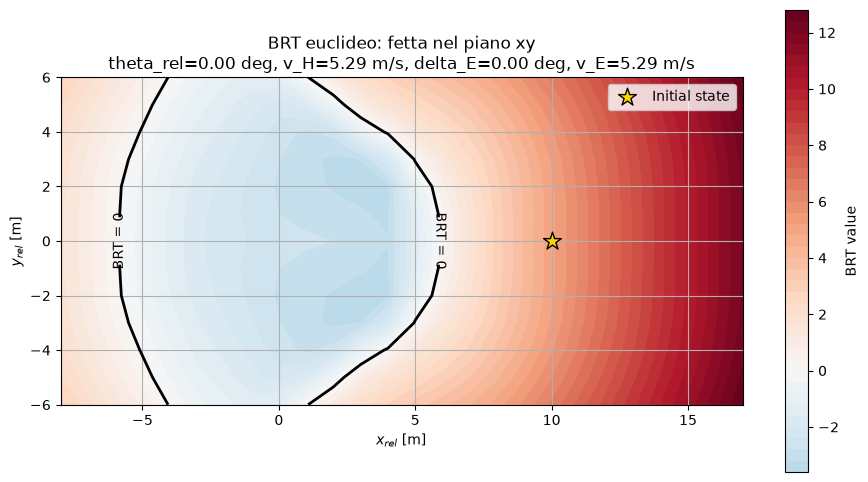

In [ ]:
brt_slice = BRT[
    :,
    :,
    i_theta,
    i_v_H,
    i_delta_E,
    i_v_E,
]

color_limit = max(
    abs(float(np.nanmin(brt_slice))),
    abs(float(np.nanmax(brt_slice))),
)

figure_2d, axis_2d = plt.subplots(
    figsize=(11, 6)
)

filled_contour = axis_2d.contourf(
    x_rel,
    y_rel,
    brt_slice.T,
    levels=41,
    cmap="RdBu_r",
    norm=TwoSlopeNorm(
        vmin=-color_limit,
        vcenter=0.0,
        vmax=color_limit,
    ),
)

if (
    np.nanmin(brt_slice) <= 0.0
    and np.nanmax(brt_slice) >= 0.0
):
    zero_contour = axis_2d.contour(
        x_rel,
        y_rel,
        brt_slice.T,
        levels=[0.0],
        colors="black",
        linewidths=2.0,
    )
    axis_2d.clabel(
        zero_contour,
        fmt={0.0: "BRT = 0"},
    )

axis_2d.scatter(
    MANUAL_INITIAL_STATE[0],
    MANUAL_INITIAL_STATE[1],
    marker="*",
    s=180,
    color="gold",
    edgecolor="black",
    label="Initial state",
    zorder=5,
)

figure_2d.colorbar(
    filled_contour,
    ax=axis_2d,
    label="BRT value",
)

axis_2d.set_xlabel(r"$x_{rel}$ [m]")
axis_2d.set_ylabel(r"$y_{rel}$ [m]")
axis_2d.set_title(
    "BRT euclideo: fetta nel piano xy\n"
    f"theta_rel={np.rad2deg(theta_selected):.2f} deg, "
    f"v_H={v_H_selected:.2f} m/s, "
    f"delta_E={np.rad2deg(delta_E_selected):.2f} deg, "
    f"v_E={v_E_selected:.2f} m/s"
)
axis_2d.set_aspect("equal", adjustable="box")
axis_2d.grid(True)
axis_2d.legend()

plt.show()

## 7. Scelta del punto iniziale ed esecuzione della simulazione

In [ ]:
initial_state = sim.select_initial_state(
    brt_data
)

initial_game = sim.evaluate_game(
    brt_data=brt_data,
    state=initial_state,
    time=0.0,
)

print("Initial-state mode:", INITIAL_STATE_MODE)
print()
for name, value in zip(
    sim.STATE_NAMES,
    initial_state,
):
    unit_value = (
        np.rad2deg(value)
        if name in {"theta_rel", "delta_E"}
        else value
    )
    unit = (
        "deg"
        if name in {"theta_rel", "delta_E"}
        else "m/s"
        if name in {"v_H", "v_E"}
        else "m"
    )
    print(f"{name:10s} = {unit_value: .6f} {unit}")

print()
print(
    f"Initial BRT value: {initial_game['brt_value']:.6f}"
)
print(
    "Initial terminal value: "
    f"{initial_game['terminal_value']:.6f}"
)

result = sim.simulate(
    brt_data=brt_data,
    initial_state=initial_state,
)

absolute_trajectories = (
    sim.reconstruct_absolute_trajectories(
        result=result,
        brt_data=brt_data,
    )
)
result.update(absolute_trajectories)

print()
print("Simulation finished.")
print("Stop reason:", result["stop_reason"])
print(f"Final time: {result['time'][-1]:.3f} s")
print("Number of samples:", len(result["time"]))
print(
    f"BRT: {result['brt_value'][0]:.6f} "
    f"-> {result['brt_value'][-1]:.6f}"
)
print(
    f"V0:  {result['terminal_value'][0]:.6f} "
    f"-> {result['terminal_value'][-1]:.6f}"
)

Initial-state mode: manual

x_rel      =  10.000000 m
y_rel      =  0.000000 m
theta_rel  =  0.000000 deg
v_H        =  6.000000 m/s
delta_E    =  0.000000 deg
v_E        =  6.000000 m/s

Initial BRT value: 4.870357
Initial terminal value: 5.470751

Simulation finished.
Stop reason: grid boundary reached
Final time: 0.714 s
Number of samples: 16
BRT: 4.870357 -> 5.235309
V0:  5.470751 -> 5.236778


## 8. Animazione

In [ ]:
animation_figure, simulation_animation, _ = (
    sim.create_animation(
        result=result
    )
)

animation_html = HTML(
    simulation_animation.to_jshtml(
        fps=ANIMATION_FPS
    )
)

plt.close(animation_figure)
display(animation_html)

## 9. Grafici della simulazione

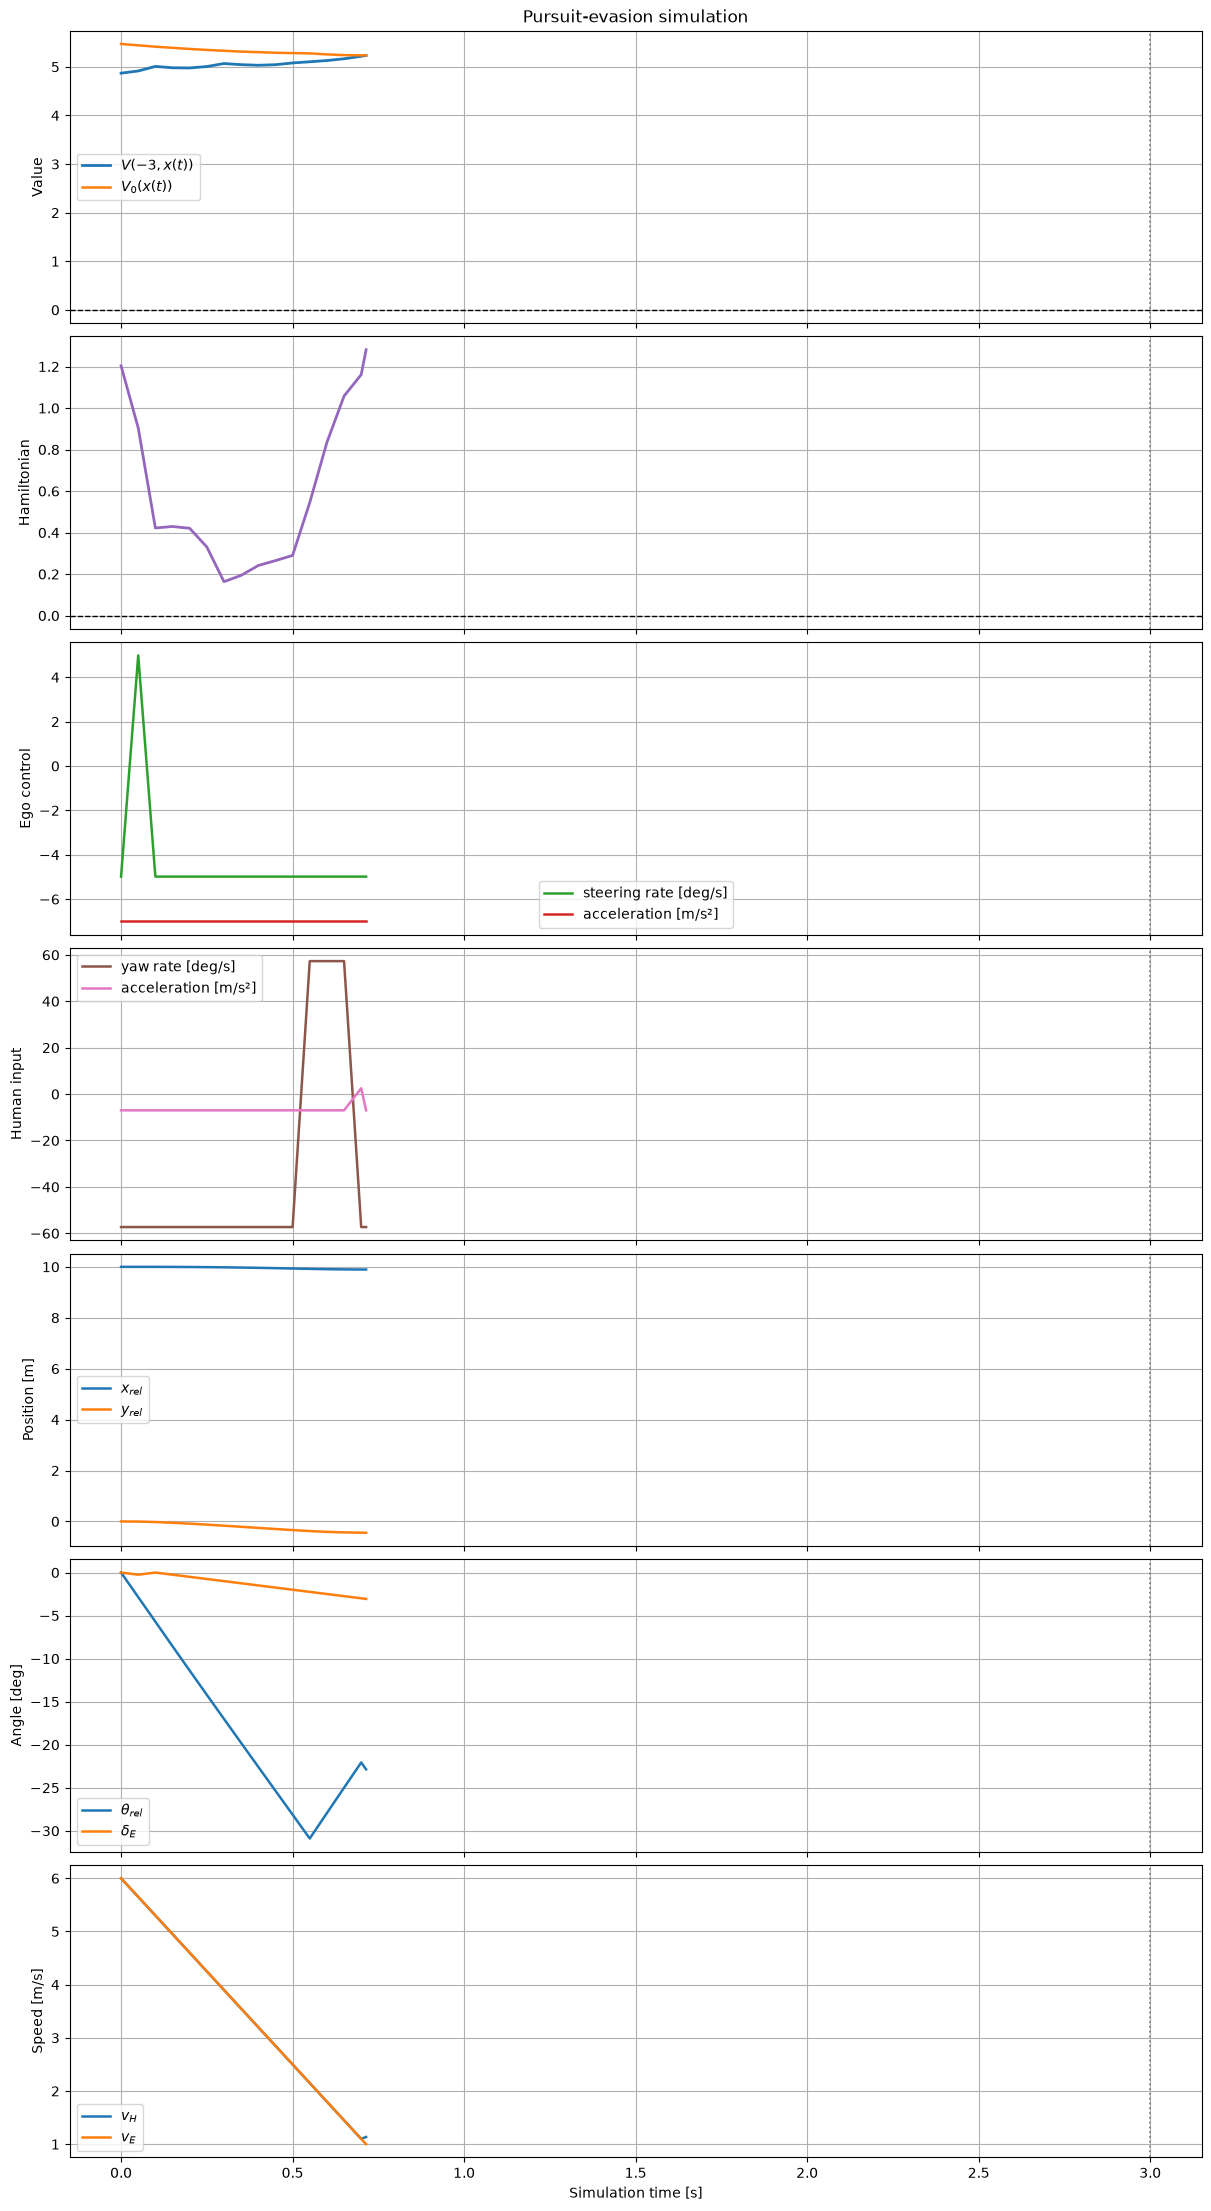

In [ ]:
static_figure, _ = sim.create_static_figure(
    result=result
)

display(static_figure)
plt.close(static_figure)